# 99. Companion: ROC, threshold i confusion matrix na małych liczbach

Ten krótki notebook jest dodatkiem do notebooków 15 i 16. Ma tylko jeden cel: wyjaśnić, jak probability/score zamienia się w klasy i jak z tego powstaje ROC.

## 1. Score to jeszcze nie klasa

Model może zwrócić score:

| id | true | score |
|---:|---:|---:|
| A | 1 | 0.90 |
| B | 1 | 0.70 |
| C | 0 | 0.60 |
| D | 1 | 0.40 |
| E | 0 | 0.30 |
| F | 0 | 0.10 |

Threshold decyduje:

$$
score \ge threshold \Rightarrow \hat y=1
$$

$$
score < threshold \Rightarrow \hat y=0
$$

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

toy = pd.DataFrame({
    'id': list('ABCDEF'),
    'true': [1, 1, 0, 1, 0, 0],
    'score': [0.90, 0.70, 0.60, 0.40, 0.30, 0.10],
})
toy

,id,true,score
0,A,1,0.9
1,B,1,0.7
2,C,0,0.6
3,D,1,0.4
4,E,0,0.3
5,F,0,0.1


In [2]:
def metrics_at_threshold(threshold):
    pred = (toy['score'] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(toy['true'], pred).ravel()
    return {
        'threshold': threshold,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'TPR_recall': tp/(tp+fn),
        'FPR': fp/(fp+tn),
    }

pd.DataFrame([metrics_at_threshold(t) for t in [0.75, 0.50, 0.35]])

,threshold,TP,FP,TN,FN,TPR_recall,FPR
0,0.75,1,0,3,2,0.333333,0.000000
1,0.50,2,1,2,1,0.666667,0.333333
2,0.35,3,1,2,0,1.000000,0.333333


## 2. ROC i AUC

ROC bierze wiele progów i dla każdego liczy:

$$
TPR=\frac{TP}{TP+FN}
$$

$$
FPR=\frac{FP}{FP+TN}
$$

AUC interpretuje się rankingowo:

> jak często losowy pozytywny przykład dostaje większy score niż losowy negatywny?

In [3]:
fpr, tpr, thresholds = roc_curve(toy['true'], toy['score'])
roc_table = pd.DataFrame({'threshold': thresholds, 'FPR': fpr, 'TPR': tpr})
print('AUC:', roc_auc_score(toy['true'], toy['score']))
roc_table

AUC: 0.888888888888889


,threshold,FPR,TPR
0,inf,0.000000,0.000000
1,0.9,0.000000,0.333333
2,0.7,0.000000,0.666667
3,0.6,0.333333,0.666667
4,0.4,0.333333,1.000000
5,0.1,1.000000,1.000000


odds(+)	OR		log(OR)
0.06		0.06		-2.773
0.12		0.12		-2.079
0.25		0.25		-1.386
0.50		0.50		-0.693
1.00		1.00		0.000
2.00		2.00		0.693
4.00		4.00		1.386
8.00		8.00		2.079
16.00		16.00		2.773


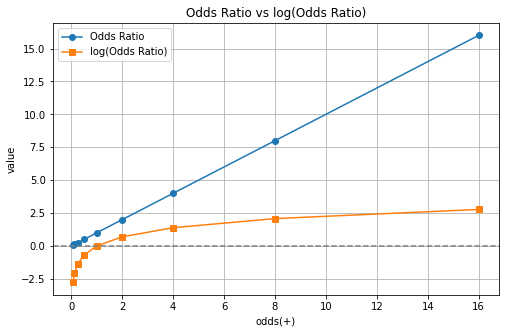

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# przykładowe odds(+)
odds_plus = np.array([1/16,1/8,0.25, 0.5, 1, 2, 4, 8,16])

# stałe odds(-)
odds_minus = 1

# odds ratio
OR = odds_plus / odds_minus

# log odds ratio
log_OR = np.log(OR)

# wypisywanie
print("odds(+)\tOR\t\tlog(OR)")
for o, or_val, log_val in zip(odds_plus, OR, log_OR):
    print(f"{o:.2f}\t\t{or_val:.2f}\t\t{log_val:.3f}")

# wykres
plt.figure(figsize=(8,5))

plt.plot(odds_plus, OR, 'o-', label='Odds Ratio')
plt.plot(odds_plus, log_OR, 's-', label='log(Odds Ratio)')

plt.axhline(0, color='gray', linestyle='--')

plt.xlabel('odds(+)')
plt.ylabel('value')
plt.title('Odds Ratio vs log(Odds Ratio)')
plt.legend()
plt.grid(True)

plt.show()

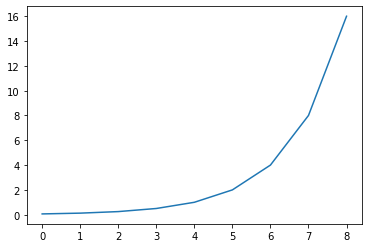

In [9]:
plt.plot(OR)

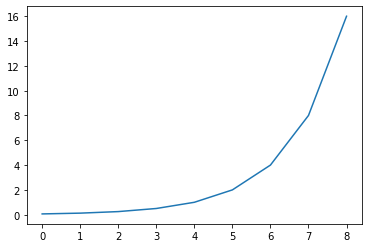

In [10]:
plt.plot(odds_plus)

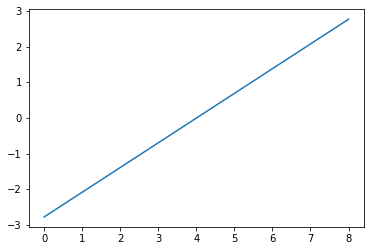

In [11]:
plt.plot(log_OR)

odds(+)		OR		log(OR)
0.0625		0.0625		-2.773
0.1250		0.1250		-2.079
0.2500		0.2500		-1.386
0.5000		0.5000		-0.693
1.0000		1.0000		0.000
2.0000		2.0000		0.693
4.0000		4.0000		1.386
8.0000		8.0000		2.079
16.0000		16.0000		2.773


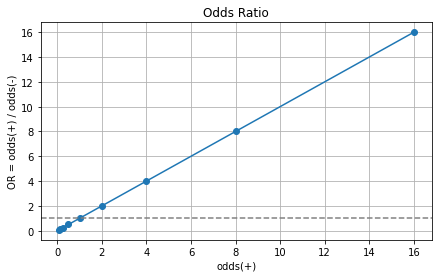

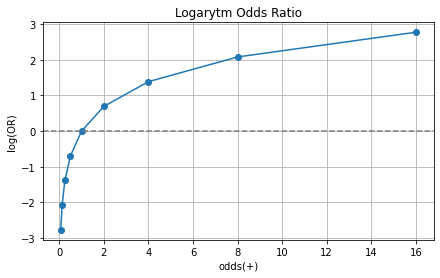

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# odds(+): wartości symetryczne wokół 1
odds_plus = np.array([1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16])

# zakładamy odds(-) = 1
odds_minus = 1

# odds ratio
OR = odds_plus / odds_minus

# log odds ratio
log_OR = np.log(OR)   # logarytm naturalny

# tabelka
print("odds(+)\t\tOR\t\tlog(OR)")
for op, or_val, log_val in zip(odds_plus, OR, log_OR):
    print(f"{op:.4f}\t\t{or_val:.4f}\t\t{log_val:.3f}")

# rysunek 1: OR
plt.figure(figsize=(7, 4))
plt.plot(odds_plus, OR, marker='o')
plt.axhline(1, linestyle='--', color='gray')
plt.xlabel("odds(+)")
plt.ylabel("OR = odds(+) / odds(-)")
plt.title("Odds Ratio")
plt.grid(True)
plt.show()

# rysunek 2: log(OR)
plt.figure(figsize=(7, 4))
plt.plot(odds_plus, log_OR, marker='o')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel("odds(+)")
plt.ylabel("log(OR)")
plt.title("Logarytm Odds Ratio")
plt.grid(True)
plt.show()